# Medical Emergency Assistant (Fine-Tuned TinyLlama)

In [ ]:
from huggingface_hub import login

login(token="here")

In [ ]:
%uv pip install datasets transformers accelerate peft bitsandbytes

Using Python 3.12.6 environment at: /usr/local
Resolved 66 packages in 328ms
⠙ Preparing packages... (0/7)
⠙ Preparing packages... (0/7)
⠙ Preparing packages... (0/7)
dill       ------------------------------ 16.00 KiB/116.86 KiB
⠙ Preparing packages... (0/7)
dill       ------------------------------ 16.00 KiB/116.86 KiB
datasets   ------------------------------     0 B/503.12 KiB
⠙ Preparing packages... (0/7)
dill       ------------------------------ 16.00 KiB/116.86 KiB
xxhash     ------------------------------     0 B/189.34 KiB
datasets   ------------------------------     0 B/503.12 KiB
⠙ Preparing packages... (0/7)
dill       ------------------------------ 16.00 KiB/116.86 KiB
xxhash     ------------------------------     0 B/189.34 KiB
datasets   ------------------------------     0 B/503.12 KiB
peft       ------------------------------     0 B/543.91 KiB
⠙ Preparing packages... (0/7)
dill       ------------------------------ 16.00 KiB/116.86 KiB
multiprocess -------------------

In [ ]:
import modal

image = (
    modal.Image.debian_slim()
    .pip_install(
        "torch",
        "transformers",
        "datasets",
        "accelerate",
        "peft",
        "bitsandbytes"
    )
)

app = modal.App("llm-training", image=image)

In [ ]:
from datasets import load_dataset

data = load_dataset("mattwesney/CoT_Reasoning_First_Responders_Triage_And_Emergencies")

README.md:   0%|          | 0.00/21.2k [00:00<?, ?B/s]

CoT_Reasoning_First_Responders_Triage_An(…):   0%|          | 0.00/18.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
print(data)


DatasetDict({
    train: Dataset({
        features: ['answer', 'id', 'metadata', 'question'],
        num_rows: 3000
    })
})


In [ ]:
data["train"].info


DatasetInfo(description='', citation='', homepage='', license='', features={'answer': Value('string'), 'id': Value('string'), 'metadata': {'difficulty': Value('int64'), 'reasoning': Value('string'), 'topic': Value('string')}, 'question': Value('string')}, post_processed=None, supervised_keys=None, builder_name='json', dataset_name='co_t_reasoning_first_responders_triage_and_emergencies', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=17563349, num_examples=3000, shard_lengths=None, original_shard_lengths=None, dataset_name='co_t_reasoning_first_responders_triage_and_emergencies')}, download_checksums={'hf://datasets/mattwesney/CoT_Reasoning_First_Responders_Triage_And_Emergencies@8f7b263e42100241fd1a4dfedd42c3e041440b07/CoT_Reasoning_First_Responders_Triage_And_Emergencies.json': {'num_bytes': 18101153, 'checksum': None}}, download_size=18101153, post_processing_size=None, dataset_size=17563349, size_in_bytes=35664502)

In [ ]:
print(data["train"].features)


{'answer': Value('string'), 'id': Value('string'), 'metadata': {'difficulty': Value('int64'), 'reasoning': Value('string'), 'topic': Value('string')}, 'question': Value('string')}


#Data Cleaning


In [ ]:
import pandas as pd

df = data["train"].to_pandas()

metadata_df = pd.json_normalize(df["metadata"])

df = pd.concat([df.drop(columns=["metadata"]), metadata_df], axis=1)

In [ ]:
df.head()

,answer,id,question,difficulty,reasoning,topic
0,A comprehensive mental health support program ...,qa_20250429_154841_100223,What are the key components of a comprehensive...,4,To effectively address the mental health chall...,"Emergency responder mental health, Mental heal..."
1,- To survive extreme urban conditions after a ...,qa_20250429_154850_655098,What are the most critical skills and knowledg...,4,"First, I considered the core elements needed f...","Urban Survival, Disaster Preparedness, Surviva..."
2,Ensuring a safe and sustainable water supply d...,qa_20250429_154900_421958,What are the critical considerations and strat...,4,"To tackle this effectively, I needed to consid...","Disaster relief, Water management, Emergency p..."
3,**Effective Strategies for Building Community ...,qa_20250429_154908_728033,What are some effective strategies for buildin...,4,"First, I should consider the various aspects o...","Disaster resilience, Community planning, Infra..."
4,"During states of emergency, governments often ...",qa_20250429_154915_812062,What legal powers do governments typically inv...,4,To answer the question about legal powers gove...,"Emergency Powers, Constitutional Law, Civil Li..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   answer      3000 non-null   object
 1   id          3000 non-null   object
 2   question    3000 non-null   object
 3   difficulty  3000 non-null   int64 
 4   reasoning   3000 non-null   object
 5   topic       3000 non-null   object
dtypes: int64(1), object(5)
memory usage: 140.8+ KB


In [ ]:
#Dropping duplicates
df = df.drop_duplicates(subset=["question"])

In [ ]:
#Removing white spaces
for col in ["question", "reasoning", "answer"]:
    df[col] = df[col].str.strip()


In [ ]:
#Filtering by difficulty
df = df[df["difficulty"] >= 2]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   answer      2998 non-null   object
 1   id          2998 non-null   object
 2   question    2998 non-null   object
 3   difficulty  2998 non-null   int64 
 4   reasoning   2998 non-null   object
 5   topic       2998 non-null   object
dtypes: int64(1), object(5)
memory usage: 164.0+ KB


#Formating Data

In [ ]:
def format_example(row):
    return f"""[USER] {row['question']} [/USER]
Answer:
{row['answer']}"""

In [ ]:
df["text"] = df.apply(format_example, axis=1)
print(df["text"][0])

[USER] What are the key components of a comprehensive mental health support program for emergency responders, and why is each component important? [/USER]
Answer:
A comprehensive mental health support program for emergency responders should include several key components to effectively address the unique stressors they face.

*   **Prevention and Education:** This involves proactive training and workshops designed to educate responders about mental health issues, stress management techniques, and the signs and symptoms of common mental health conditions such as PTSD, anxiety, and depression. This also includes promoting a culture of open communication and reducing the stigma associated with seeking mental health support.

    *   Why: Prevention and education are crucial because they equip responders with the knowledge and skills to recognize mental health challenges in themselves and their colleagues early on. It also helps normalize conversations about mental health, encouraging indi

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   answer      2998 non-null   object
 1   id          2998 non-null   object
 2   question    2998 non-null   object
 3   difficulty  2998 non-null   int64 
 4   reasoning   2998 non-null   object
 5   topic       2998 non-null   object
 6   text        2998 non-null   object
dtypes: int64(1), object(6)
memory usage: 251.9+ KB


#Dataset Split

In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(df[["text"]])

dataset = dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = dataset["train"]
val_dataset = dataset["test"]

print("Train Dataset Size", len(train_dataset))
print("Validation Dataset Size", len(val_dataset))

Train Dataset Size 2698
Validation Dataset Size 300


In [ ]:
val_dataset_raw = val_dataset

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(example):
    tokenized = tokenizer(
        example["text"],
        truncation=True,
        max_length=512,
        padding="max_length"
    )

    attention_mask = tokenized["attention_mask"]
    tokenized["labels"] = tokenized["input_ids"].copy()

    return tokenized

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)



tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Map:   0%|          | 0/2698 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format(type="torch",
    columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch",
    columns=["input_ids", "attention_mask", "labels"])

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    dtype="auto"
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8, #16
    lora_alpha=16,#32
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./emergency_assistant",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    logging_steps=50,
    num_train_epochs=3,
    learning_rate=3e-4,
    eval_strategy="steps",
    save_strategy="epoch",
    fp16=True,
    save_total_limit=2,
    push_to_hub=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer
)

Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [ ]:
import time

start = time.time()
trainer.train()
end = time.time()
print(f"Training completed in {end - start:.2f} seconds")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss
50,1.535900,1.266685
100,1.264300,1.227301
150,1.232200,1.208128
200,1.212400,1.194981
250,1.217600,1.185367
300,1.192900,1.176541
350,1.180600,1.169714
400,1.188700,1.164008
450,1.153800,1.158444
500,1.166300,1.153867


Training completed in 946.93 seconds


Collected 20 training points


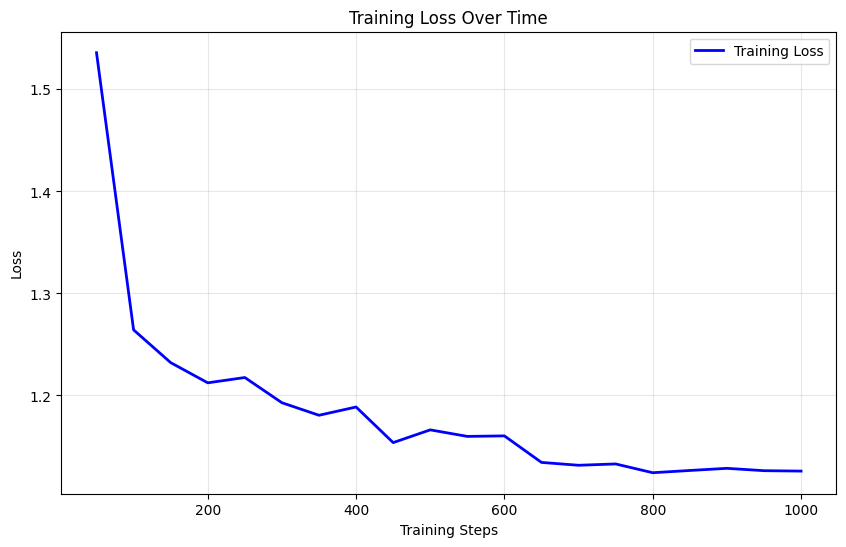

In [ ]:
import matplotlib.pyplot as plt

# Extract training loss
train_loss = []
steps = []

for log in trainer.state.log_history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])

print(f"Collected {len(train_loss)} training points")
plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, 'b-', linewidth=2, label='Training Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
model.save_pretrained("./emergency_assistant")
tokenizer.save_pretrained("./emergency_assistant")

('./emergency_assistant/tokenizer_config.json',
 './emergency_assistant/special_tokens_map.json',
 './emergency_assistant/chat_template.jinja',
 './emergency_assistant/tokenizer.model',
 './emergency_assistant/added_tokens.json',
 './emergency_assistant/tokenizer.json')

In [ ]:
tuned_model = AutoModelForCausalLM.from_pretrained(
    "./emergency_assistant",
    device_map="auto",
    dtype="auto"
)

In [ ]:
from transformers import pipeline

base_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

tuned_pipe = pipeline(
    "text-generation",
    model=tuned_model,
    tokenizer=tokenizer
)

Device set to use cuda:0
Device set to use cuda:0


In [ ]:
question = "A person is unconscious but breathing after a fall. What should I do?"

prompt = f"""### Instruction:
Answer this medical emergency question:
{question}

### Response:
"""

print("BASE MODEL:\n")
print(base_pipe(prompt, max_new_tokens=300)[0]["generated_text"])

print("\nFINE-TUNED MODEL:\n")
print(tuned_pipe(prompt, max_new_tokens=300)[0]["generated_text"])

BASE MODEL:

### Instruction:
Answer this medical emergency question:
A person is unconscious but breathing after a fall. What should I do?

### Response:

Here's my answer:

*    **Immediate Action:**
    *   **Situation Assessment:** After assessing the patient's level of consciousness, I will immediately administer CPR (Chest Compressions, Rescue Breaths, Rapid CPR, Knee Tap). This is the **first and most crucial** action.
    *   **Basic Airway Managment:**
        *   I will ensure the patient's airway is open and free from obstruction. Use a rescue apparatus, such as a nasal airway or a gurney, if necessary to ensure an open airway. If the airway is compromised, I will administer oxygen, a nasal spray, or a chin-up mask for ventilation.
        *   If the person is not breathing, I will check for other airway obstructions (e.g., obstruction from a foreign object, bleeding).
    *   **Gas Management:**
        *   I will administer gases such as hypertonic saline (HTS) to assist i

In [ ]:
%uv pip install -q rouge_score evaluate nltk

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import evaluate

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

predictions = []
references = []

model.eval()

for example in val_dataset_raw.select(range(50)):

    full_text = example["text"]

    # Extract instruction
    prompt = full_text.split("### Response:")[0] + "### Response:\n"

    output = tuned_pipe(
        prompt,
        max_new_tokens=100,
        do_sample=False
    )[0]["generated_text"]

    prediction = output.split("### Response:")[-1].strip()

    # Extract reference
    reference = full_text.split("### Response:")[-1].strip()

    predictions.append(prediction)
    references.append(reference)


# ROUGE
rouge_score = rouge.compute(
    predictions=predictions,
    references=references
)

# BLEU
bleu_score = bleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

print("ROUGE:", rouge_score)
print("BLEU:", bleu_score)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


ROUGE: {'rouge1': np.float64(0.11136923199647189), 'rouge2': np.float64(0.04880340358949674), 'rougeL': np.float64(0.0775506878230002), 'rougeLsum': np.float64(0.10792602535811405)}
BLEU: {'bleu': 2.1999717858509117e-05, 'precisions': [0.8015397775876818, 0.4960948799537171, 0.3246257704725565, 0.2016681560917486], 'brevity_penalty': 5.4769600709952515e-05, 'length_ratio': 0.09248661620823334, 'translation_length': 3507, 'reference_length': 37919}


In [ ]:
import pandas as pd


results = {
    "Metric": [
        "Loss",
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU Score"
    ],
    "Value": [
        1.125900,
        rouge_score["rouge1"],
        rouge_score["rouge2"],
        rouge_score["rougeL"],
        bleu_score["bleu"]
    ]
}

results_df = pd.DataFrame(results)

results_df

,Metric,Value
0,Loss,1.125900
1,ROUGE-1,0.111369
2,ROUGE-2,0.048803
3,ROUGE-L,0.077551
4,BLEU Score,0.000022


In [ ]:
%uv pip install gradio

Using Python 3.12.6 environment at: /usr/local
⠙ gradio==6.6.0                                                                 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Resolved 53 packages in 225ms
⠙ Preparing packages... (0/11)
⠙ Preparing packages... (0/11)
ffmpy      ------------------------------     0 B/5.48 KiB
⠙ Preparing packages... (0/11)
ffmpy      ------------------------------     0 B/5.48 KiB
⠙ Preparing packages... (0/11)
ffmpy      ------------------------------ 5.48 KiB/5.48 KiB
⠙ Preparing packages... (0/11)
ffmpy      ------------------------------ 5.48 KiB/5.48 KiB
groovy     ------------------------------     0 B/13.76 KiB
⠙ Preparing packages... (0/11)
ffmpy      ------------------------------ 5.48 KiB/5.48 KiB
groovy     ------------------------------ 13.76 KiB/13.76 KiB
⠙ Preparing packages... (0/11)
ffmpy      ------------------------------ 5.48 KiB/5.48 KiB
groovy     ------------------------------ 13.76 KiB/13.76 KiB
python-multipart ------------------------------     0 B/24.00 KiB
⠙ Preparing packages... (0/11)
ffmpy      ------------------------------ 5.48 KiB/5.48 KiB
groovy     ------------------------------ 13.76 KiB/13

In [ ]:
import gradio as gr

def chatbot(question):

    prompt = f"""### Instruction:
{question}

### Response:
"""

    output = tuned_pipe(
        prompt,
        max_new_tokens=400,
        do_sample=False,
        eos_token_id=None
    )[0]["generated_text"]

    response = output.replace(prompt, "").strip()
    return response

gr.Interface(
    fn=chatbot,
    inputs=gr.Textbox(lines=3, placeholder="Enter your emergency question..."),
    outputs=gr.Textbox(lines=15),
    title="Medical Emergency Assistant",
    description="Here To Help During Emergencies"
).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6f5412668c709b5ef2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
